# Neural oscillations underlying group coordination


This project investigates neural oscillations underlying social interaction, using data from a EEG-hyperscanning experiment in which three people simultaneously engaged in group coordination. A central portion of the project also involves familiarisation with EEG data, including preprocessing and visualisation. 

In [3]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt

In [4]:
DATA_DIR = r"C:\Users\clara\OneDrive - Danmarks Tekniske Universitet\Skrivebord\DTU\Human Centeret Artificial Intelligence\Thesis\data\preprocessed"

PARTICIPANT_ID = "301"
PARTICIPANT = 1

EPOCH_FILE = os.path.join(DATA_DIR, f"{PARTICIPANT_ID}_p{PARTICIPANT}_clean-epo.fif")

In [5]:
# Loading epochs
epochs = mne.read_epochs(EPOCH_FILE, preload=True)

# sampling frequency
sfreq = epochs.info["sfreq"]

Reading C:\Users\clara\OneDrive - Danmarks Tekniske Universitet\Skrivebord\DTU\Human Centeret Artificial Intelligence\Thesis\data\preprocessed\301_p1_clean-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...    5500.00 ms
        0 CTF compensation matrices available
Not setting metadata
294 matching events found
No baseline correction applied
0 projection items activated


In [6]:
# Listing conditions
print("Conditions:", list(epochs.event_id.keys()))

Conditions: ['Condition_0', 'Condition_1', 'Condition_2', 'Condition_3', 'Condition_4', 'Condition_5', 'Condition_6', 'Condition_7', 'Condition_8', 'Condition_9']


**MORLET WAVELET PARAMETERS**

In [7]:
# frequencies of interest
foi = np.linspace(1, 30, 30, dtype=int)

# number of cycles per frequency
n_cycles = 3 + 0.5 * foi

# baseline window (seconds)
baseline_window = (-0.25, 0)

**Time Frequency Representation per condition**


In [8]:
tfr_results = {}

for condition in epochs.event_id:

    # select epochs for condition
    epochs_cond = epochs[condition]

    # compute time-frequency power per epoch
    tfr = epochs_cond.compute_tfr(
        method="morlet",
        freqs=foi,
        n_cycles=n_cycles,
        return_itc=False,
        average=False
    )

    # average across epochs
    tfr_avg = tfr.average()

    # baseline correction
    tfr_avg.apply_baseline(baseline_window, mode="percent")

    # convert to percent
    tfr_avg.data *= 100

    # store result
    tfr_results[condition] = tfr_avg

Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


No baseline correction applied


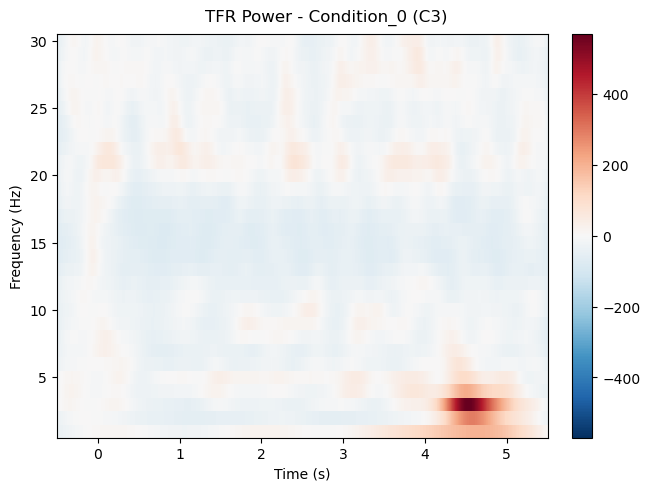

No baseline correction applied


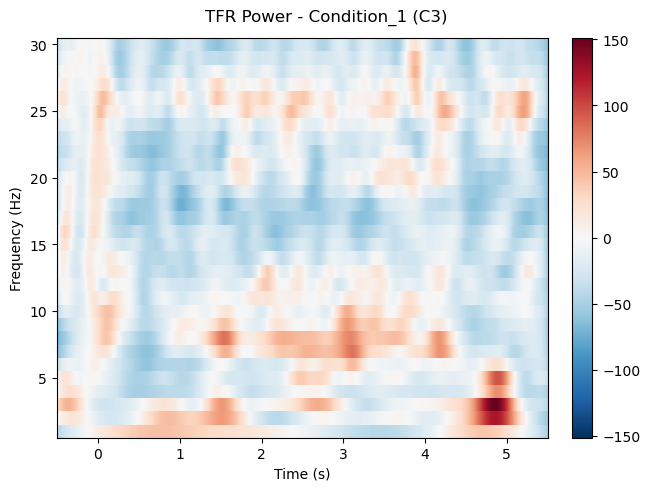

No baseline correction applied


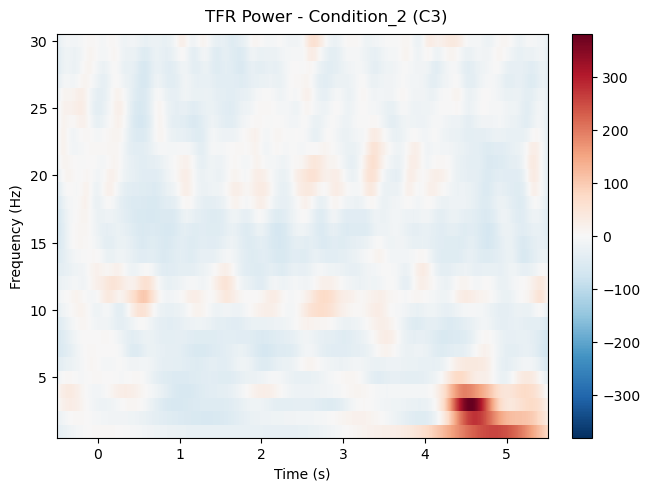

No baseline correction applied


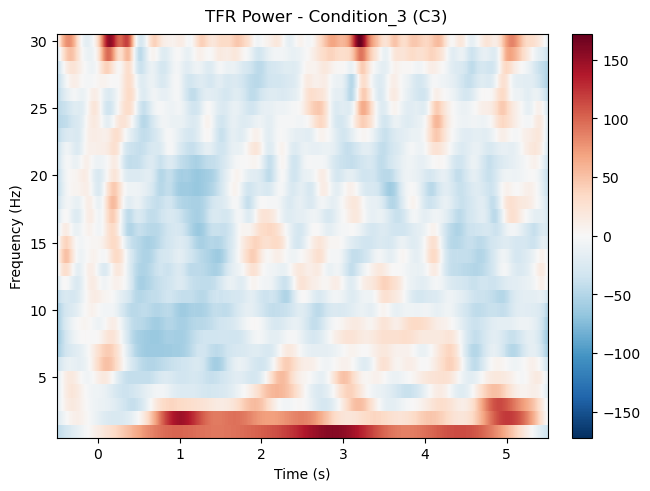

No baseline correction applied


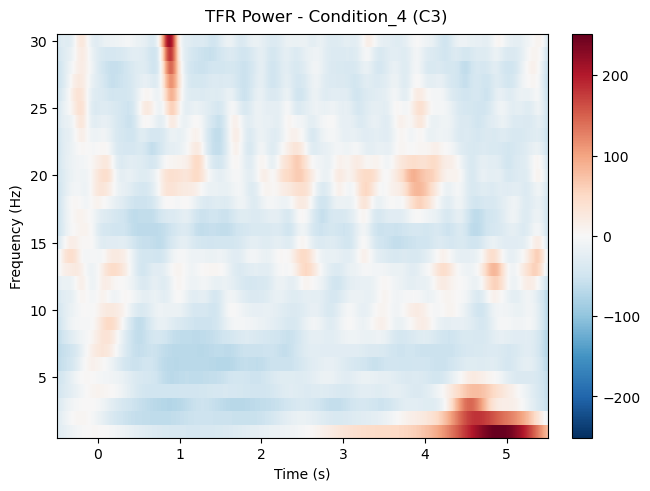

No baseline correction applied


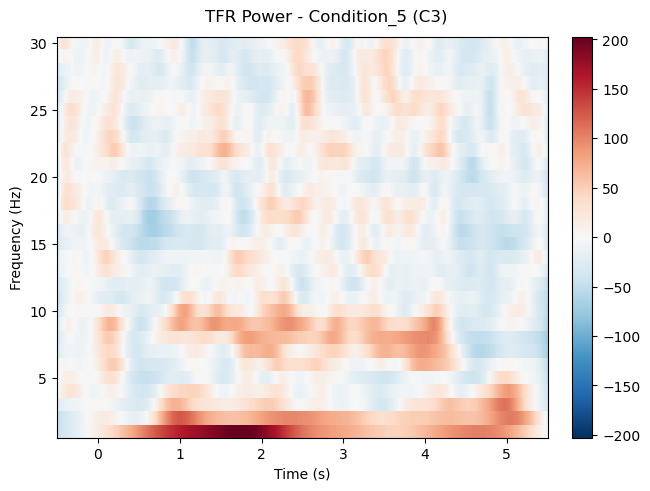

No baseline correction applied


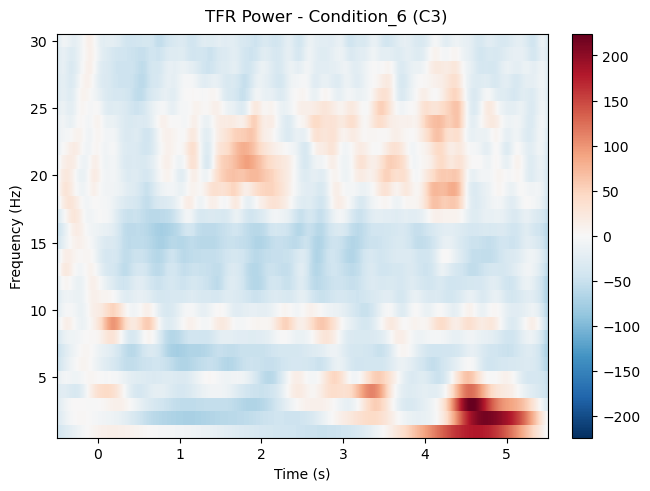

No baseline correction applied


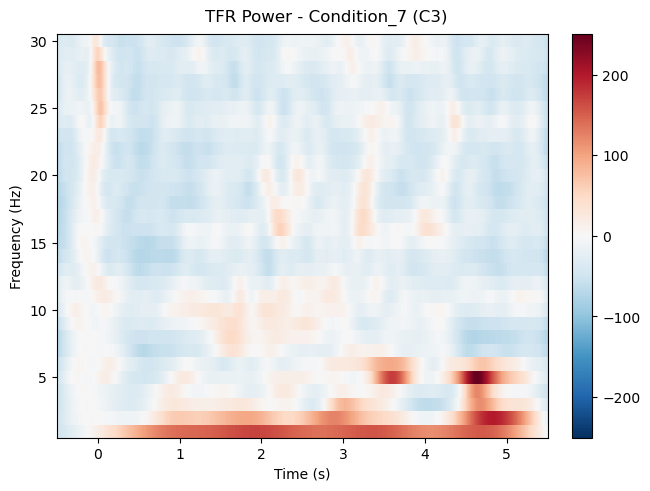

No baseline correction applied


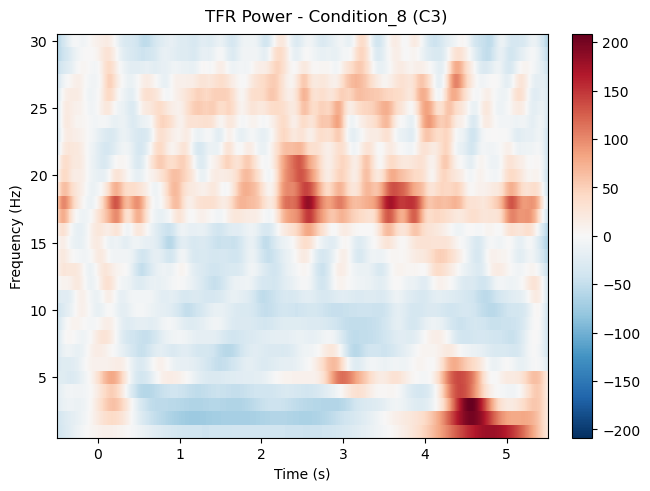

No baseline correction applied


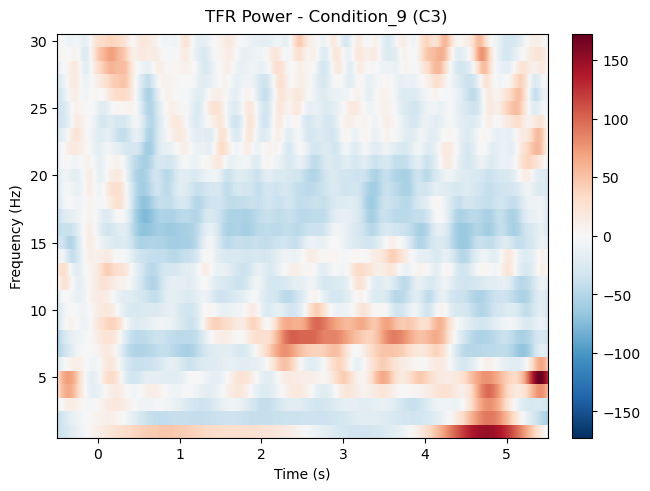

In [10]:
for condition, tfr in tfr_results.items():

    tfr.plot(
        picks="C3",   # change to O1/O2/Oz later
        title=f"TFR Power - {condition} (C3)",
        baseline=None
    )

plt.show()

### Video illustrations

No baseline correction applied
No baseline correction applied
No baseline correction applied


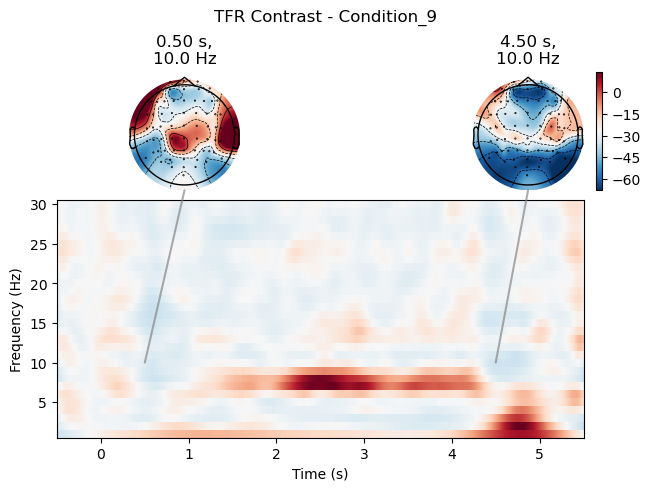

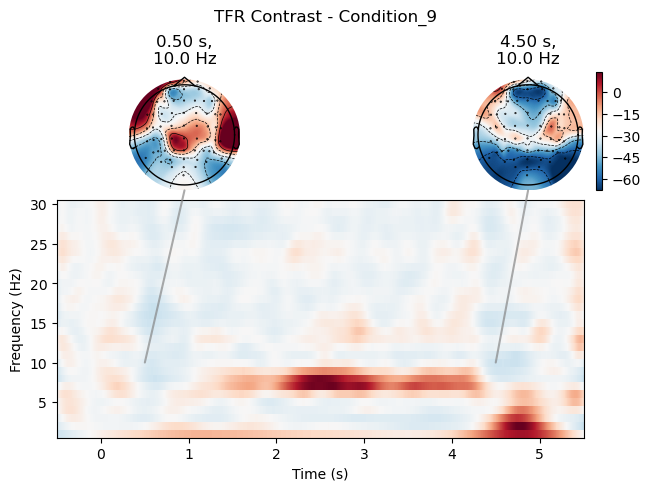

In [16]:
tfr_contrast = tfr_results[condition]
tfr_contrast.plot_joint(
    title=f"TFR Contrast - {condition}",
    timefreqs=[(0.5, 10), (4.5, 10)]
)

In [11]:
target = epochs[condition].average()

No projector specified for this dataset. Please consider the method self.add_proj.


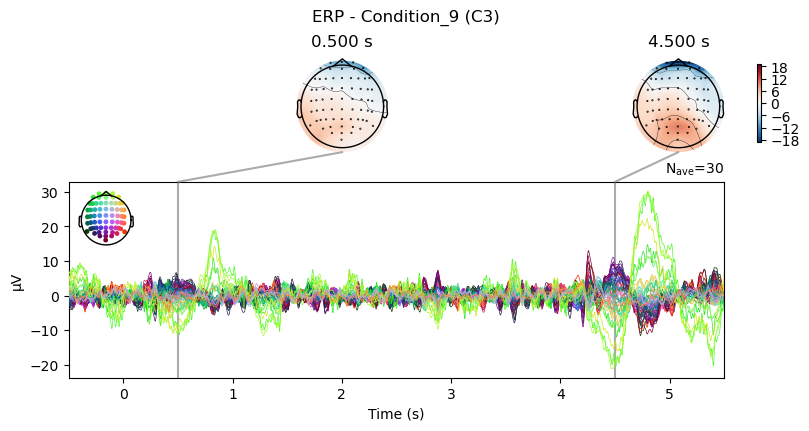

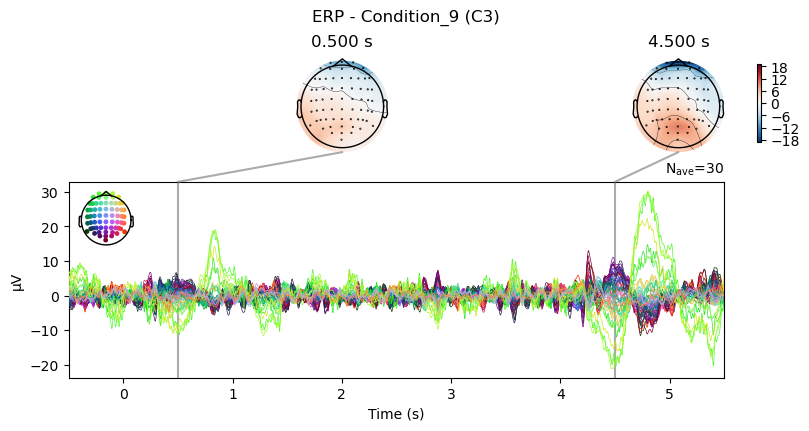

In [13]:
target.plot_joint(title=f"ERP - {condition} (C3)", times=[0.5, 4.5])